In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
df = pd.read_csv(r"C:\Users\MOHINI\Downloads\European_Bank.csv")
print(df.shape)
print(df.dtypes)
print(df.head())

(10000, 14)
Year                 int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object
   Year  CustomerId   Surname  CreditScore Geography  Gender  Age  Tenure  \
0  2025    15634602  Hargrave          619    France  Female   42       2   
1  2025    15647311      Hill          608     Spain  Female   41       1   
2  2025    15619304      Onio          502    France  Female   42       8   
3  2025    15701354      Boni          699    France  Female   39       1   
4  2025    15737888  Mitchell          850     Spain  Female   43       2   

     Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  \
0       0.00              1          1               1    

In [3]:
df.drop(columns=['Year', 'CustomerId', 'Surname'], inplace=True)
print(df.columns.tolist())


['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


In [4]:
print(df.isnull().sum())

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


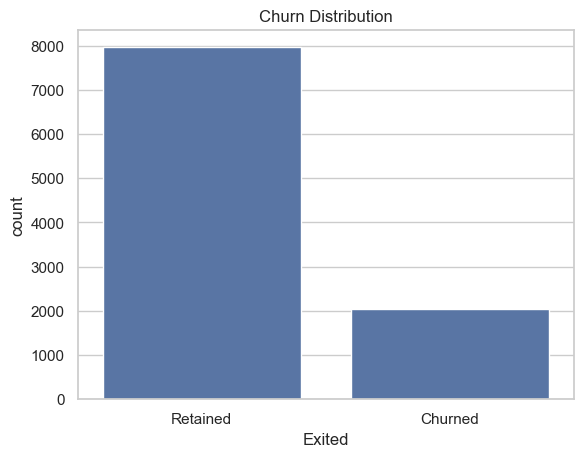

In [5]:
churn_counts = df['Exited'].value_counts()
churn_pct = df['Exited'].value_counts(normalize=True) * 100

print(churn_counts)
print(churn_pct)

sns.countplot(x='Exited', data=df)
plt.title('Churn Distribution')
plt.xticks([0, 1], ['Retained', 'Churned'])
plt.show()

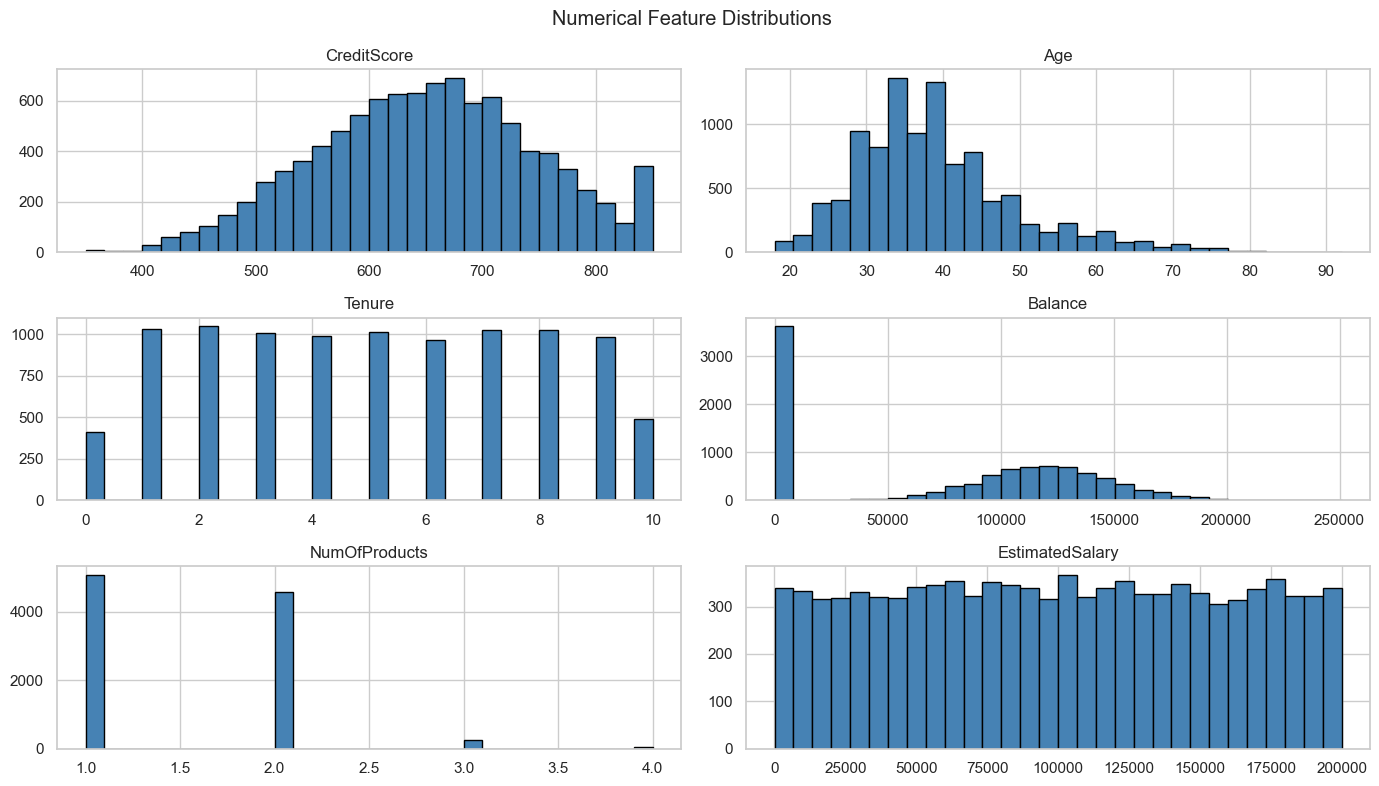

In [6]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

df[num_cols].hist(bins=30, figsize=(14, 8), color='steelblue', edgecolor='black')
plt.suptitle('Numerical Feature Distributions')
plt.tight_layout()
plt.show()

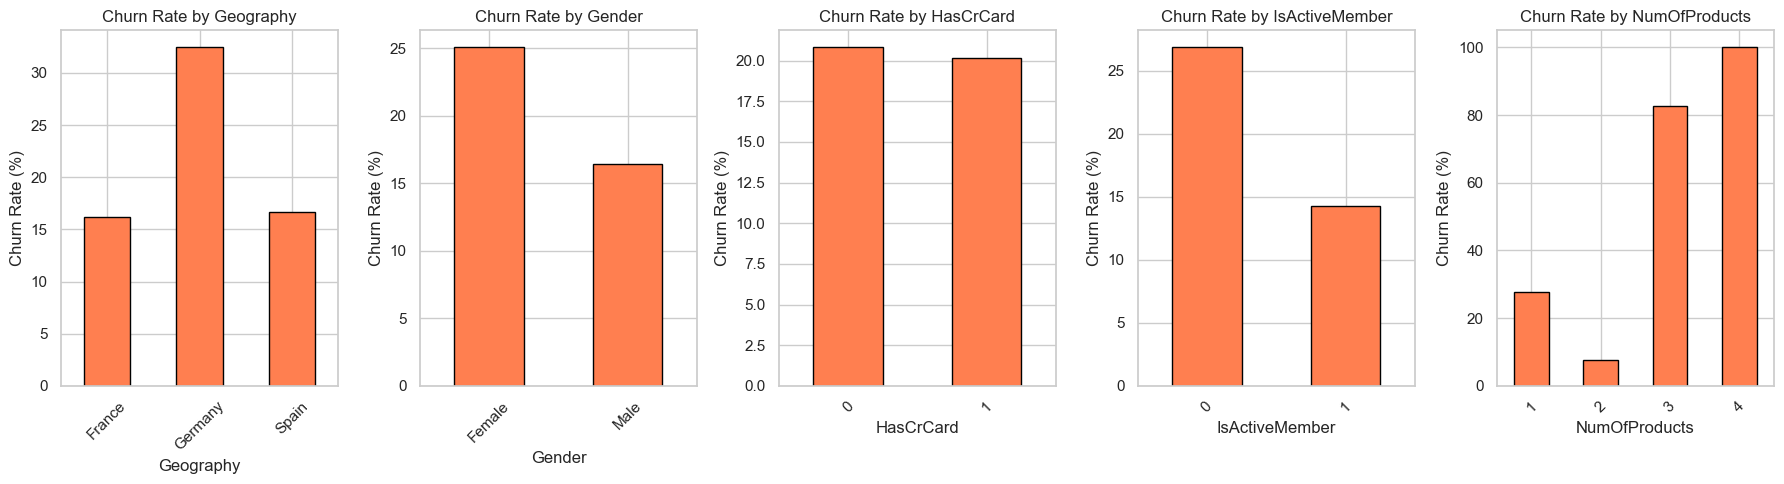

In [7]:
cat_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 5))

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['Exited'].mean() * 100
    churn_rate.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

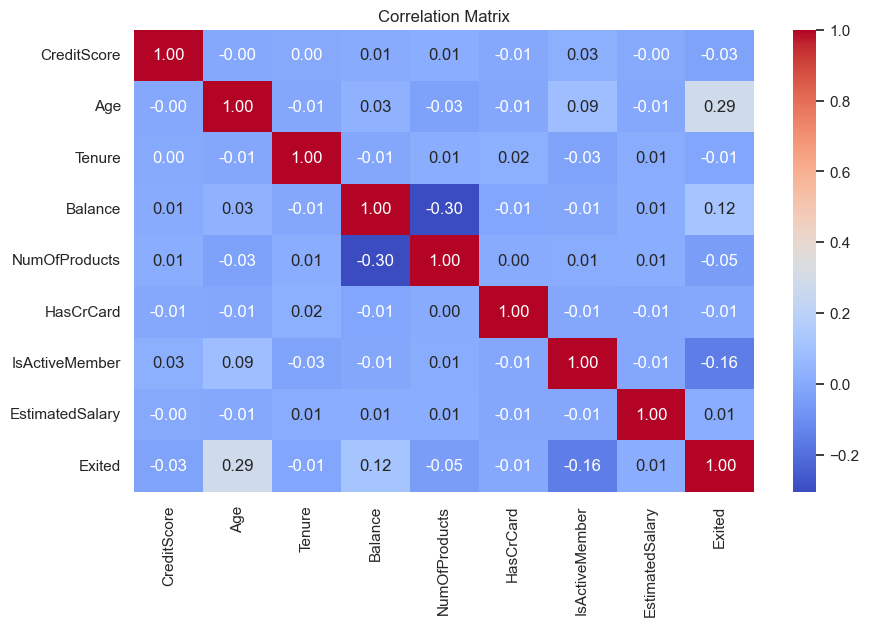

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title('Correlation Matrix')
plt.show()

C:\Users\MOHINI\AppData\Local\Temp\ipykernel_8396\3935287835.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Age', data=df, ax=axes[0], palette='Set2')
C:\Users\MOHINI\AppData\Local\Temp\ipykernel_8396\3935287835.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Retained', 'Churned'])
C:\Users\MOHINI\AppData\Local\Temp\ipykernel_8396\3935287835.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y='Balance', data=df, ax=axes[1], palette='Set2')
C:\Users\MOHINI\AppData\Local\Temp\ipykernel_8396\3935287835.py:9: UserWarning: set_ticklabels() should on

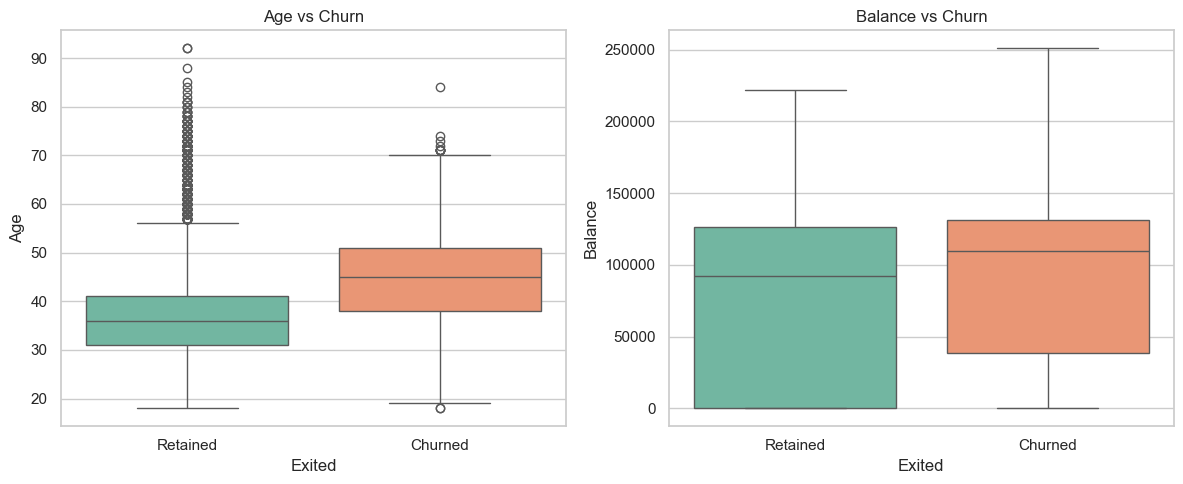

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Exited', y='Age', data=df, ax=axes[0], palette='Set2')
axes[0].set_title('Age vs Churn')
axes[0].set_xticklabels(['Retained', 'Churned'])

sns.boxplot(x='Exited', y='Balance', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Balance vs Churn')
axes[1].set_xticklabels(['Retained', 'Churned'])

plt.tight_layout()
plt.show()